In [1]:
from chembayes import Optimizer
import pandas as pd

c:\Users\jamar\Documents\05_PYTHON PROJECTS\chembayes\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Example data loading
data = pd.read_csv('data/test_data.csv')

In [3]:
data

,x1_num_std_normal,x2_num_uniform_m50_50,x3_num_lognormal,x4_num_exponential,x5_num_shifted_normal,c1_cat_ABC,c2_cat_XY,c3_cat_colors,y1,y2,y3
0,0.304717,-23.413004,2.707860,12.542484,110.601294,C,X,green,-1.827227,-0.835750,-0.397587
1,-1.039984,46.917638,2.404682,12.681845,85.906535,C,Y,purple,2.999333,6.040927,1.697861
2,0.750451,27.875090,3.501463,3.372740,96.407772,A,X,orange,3.804071,5.992363,2.627563
3,0.940565,21.689019,7.811612,8.689367,103.935522,A,Y,blue,2.786430,3.848984,1.497805
4,-1.951035,-5.063850,2.909376,30.781850,116.410570,B,X,purple,1.282209,3.942867,1.500168
...,...,...,...,...,...,...,...,...,...,...,...
95,-1.447112,37.456204,0.396534,42.569109,109.079312,A,Y,red,1.863651,5.957251,0.603711
96,-1.322700,-30.356533,2.275870,0.527184,93.826539,B,X,purple,-0.273600,1.006240,0.185088
97,-0.997247,-18.967633,3.103046,53.296195,118.710943,B,X,red,1.697145,3.350913,0.324144
98,0.399774,27.740484,3.393954,0.634325,63.371878,A,X,red,3.207384,4.447830,1.738293


In [4]:
# Inputs selection
inputs = [
    'x1_num_std_normal',
    'x2_num_uniform_m50_50',
    'x3_num_lognormal',
    'x4_num_exponential',
    'x5_num_shifted_normal',
    'c1_cat_ABC',
    'c2_cat_XY',
    'c3_cat_colors'
]

In [5]:
# Single output optimization
opt = Optimizer(data=data, inputs=inputs, output='y1')

In [6]:
opt.summary()


--- Optimization results ---
Model score (R²): 1.0000
Best input parameters:
  x1_num_std_normal: 1.9094382406785164
  x2_num_uniform_m50_50: 46.34833791679714
  x3_num_lognormal: 9.246250498644379
  x4_num_exponential: 145.5989489209443
  x5_num_shifted_normal: 79.38798405626747
  c1_cat_ABC: A
  c2_cat_XY: X
  c3_cat_colors: red
Best predicted y1: 5.3279 ± 1.3613


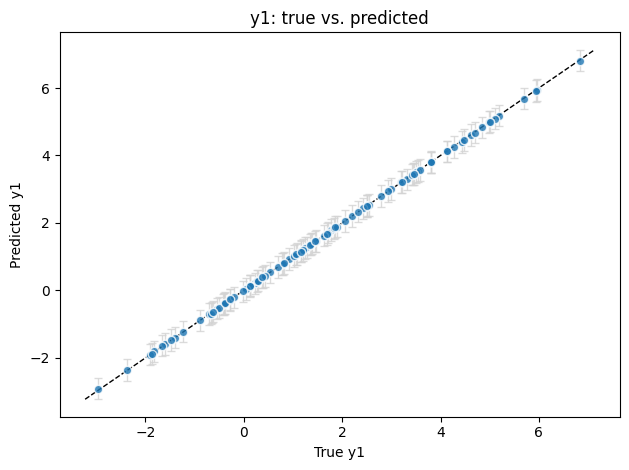

In [7]:
opt.true_vs_pred_plot()

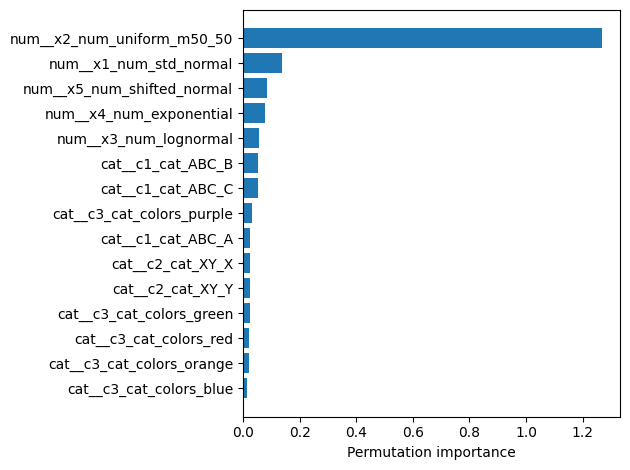

In [8]:
opt.permutation_importance_plot()

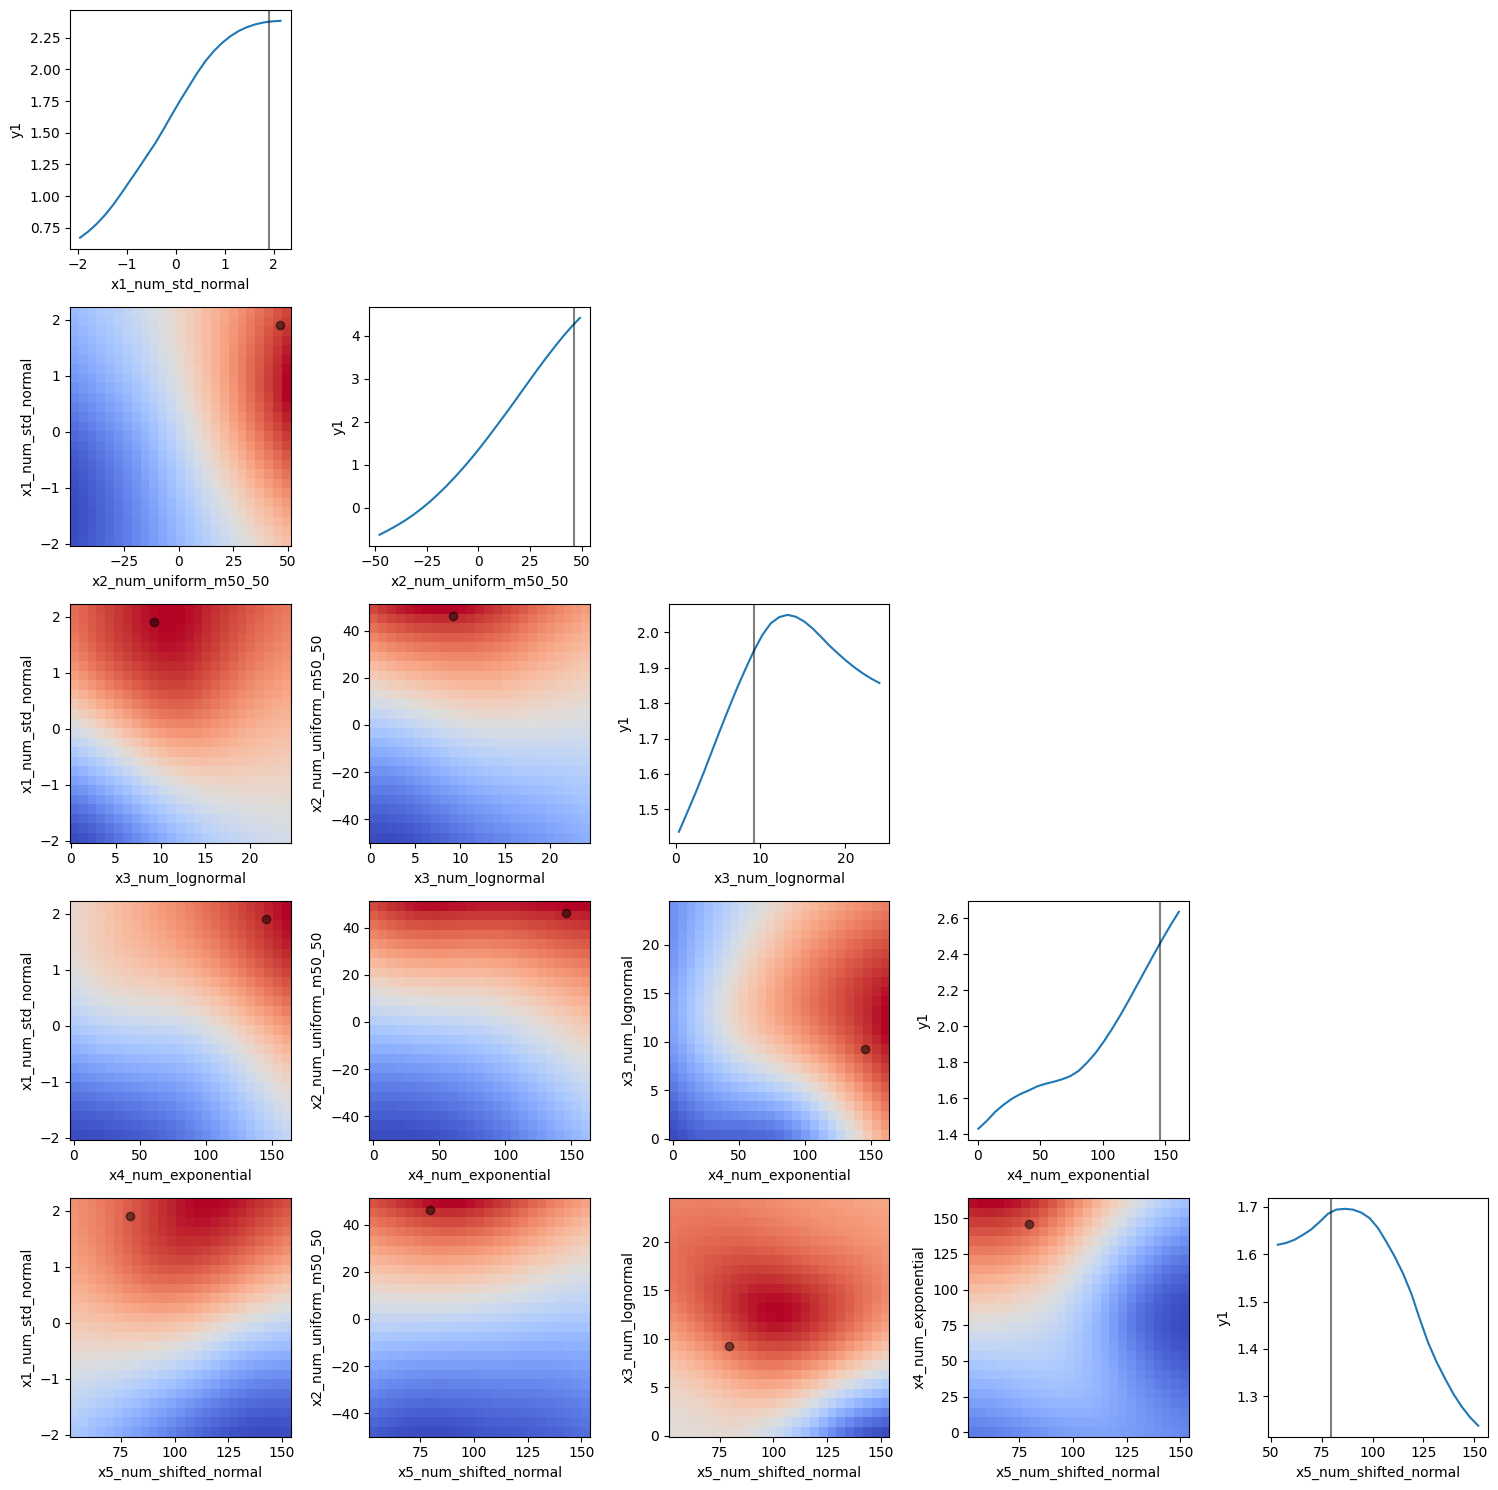

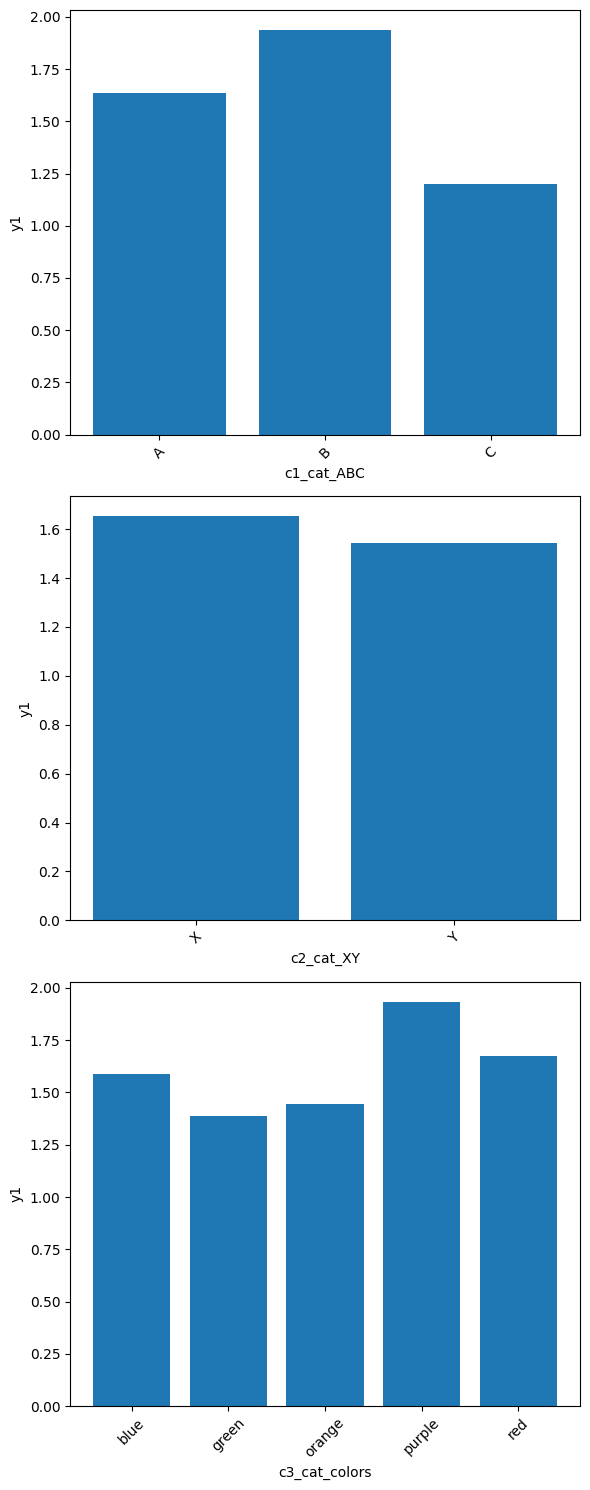

In [9]:
opt.partial_dependence_plot()

In [10]:
# Weighted outputs optimization
outputs = {
    'y1': 0.75,
    'y2': 0.5,
    'y3': 0.25
}

In [11]:
opt2 = Optimizer(data, inputs=inputs, output=outputs)

In [12]:
opt2.summary()


--- Optimization results ---
Model score (R²): 0.9667
Best input parameters:
  x1_num_std_normal: 1.7075874956292452
  x2_num_uniform_m50_50: 46.49128389009229
  x3_num_lognormal: 17.51823093346039
  x4_num_exponential: 147.58196315818583
  x5_num_shifted_normal: 89.71795049917856
  c1_cat_ABC: B
  c2_cat_XY: Y
  c3_cat_colors: purple
Best predicted objective: 2.2215 ± 0.9585


In [13]:
opt2.plot_true_vs_pred()

AttributeError: 'Optimizer' object has no attribute 'plot_true_vs_pred'

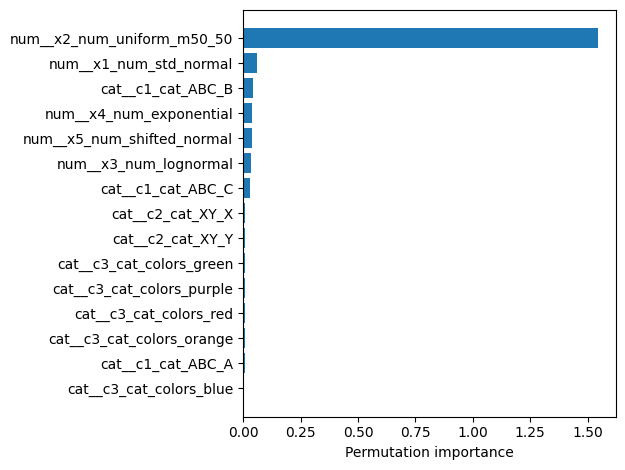

In [ ]:
opt2.permutation_importance_plot()

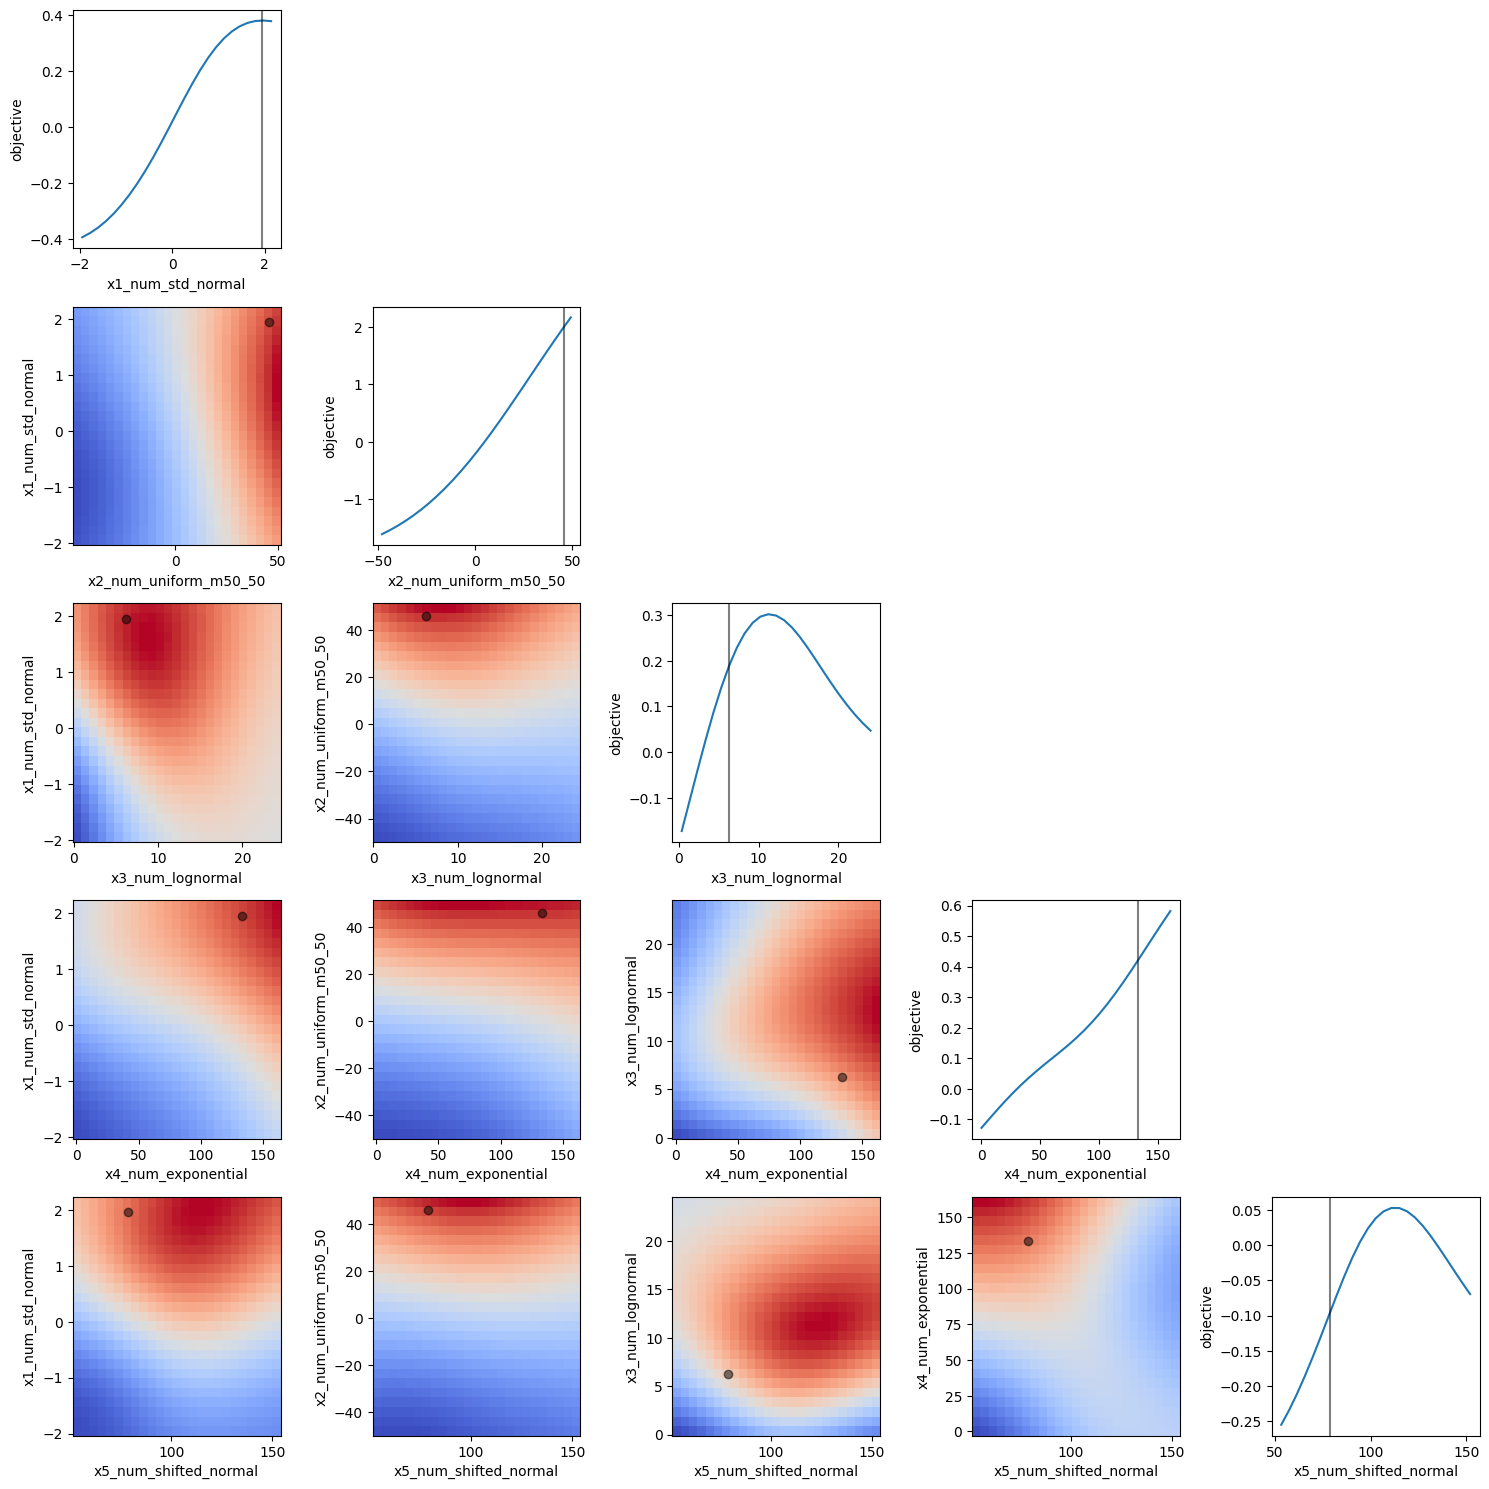

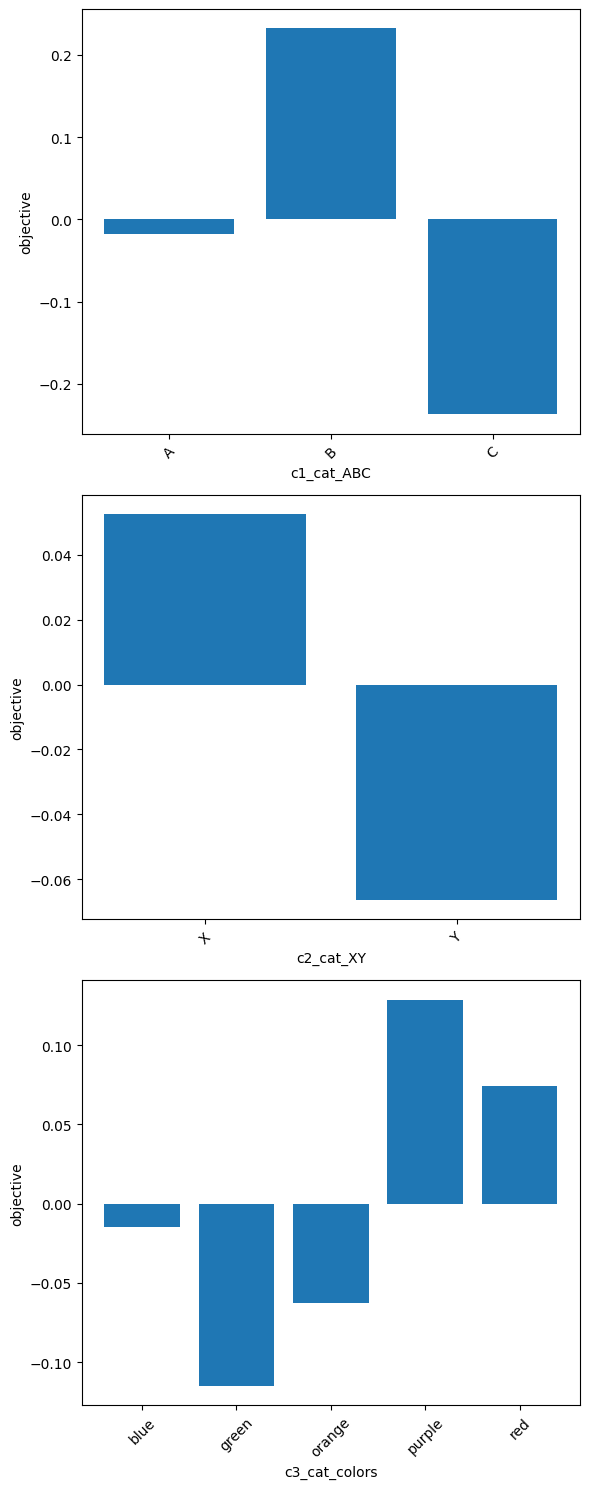

In [ ]:
opt2.partial_dependence_plot()